In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-06-02-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-04-01-02-01-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-02-01-01-02-02.wav
/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav


In [3]:
dataset_path = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio"

In [4]:
from scipy.io import wavfile

sample_audio = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_07/03-01-07-01-01-02-07.wav"

sample_rate, signal = wavfile.read(sample_audio)

print("Sample Rate:", sample_rate)
print("Signal Shape:", signal.shape)
print("Signal Type:", signal.dtype)

Sample Rate: 48000
Signal Shape: (168168,)
Signal Type: int16


/tmp/ipykernel_58/134105517.py:5: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, signal = wavfile.read(sample_audio)


In [5]:
duration = len(signal) / sample_rate

print("Duration:", duration, "seconds")

Duration: 3.5035 seconds


In [6]:
print(signal[:20])

[ 0  2  1  0  0  0  0 -1  0  0  0  0  0  0  0  0  0 -1  0  0]


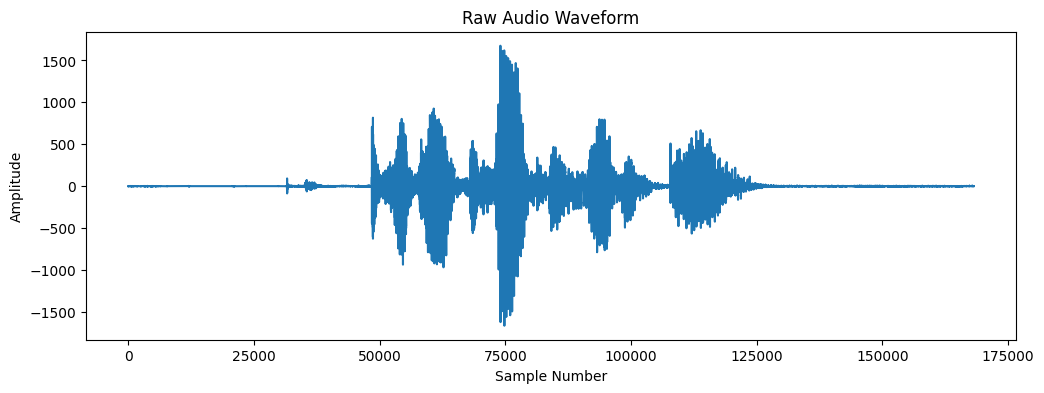

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(signal)

plt.title("Raw Audio Waveform")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")

plt.show()

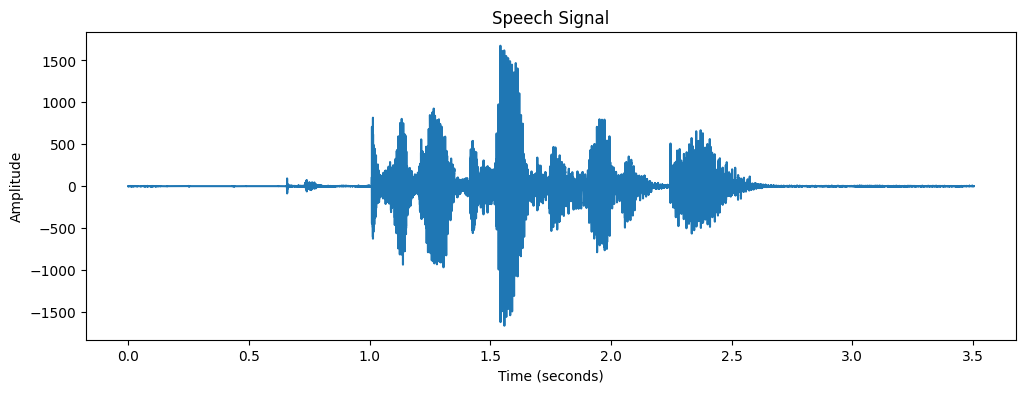

In [9]:
import numpy as np

time_axis = np.linspace(
    0,
    len(signal)/sample_rate,
    num=len(signal)
)

plt.figure(figsize=(12,4))

plt.plot(time_axis, signal)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Speech Signal")

plt.show()

In [11]:
import warnings
from scipy.io.wavfile import WavFileWarning

warnings.filterwarnings("ignore", category=WavFileWarning)
import os
from scipy.io import wavfile

durations = []

for actor in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):

        if file.endswith(".wav"):

            filepath = os.path.join(actor_path, file)

            sample_rate, signal = wavfile.read(filepath)

            duration = len(signal) / sample_rate

            durations.append(duration)

In [12]:
print("Minimum Duration:", min(durations))
print("Maximum Duration:", max(durations))
print("Average Duration:", sum(durations)/len(durations))

Minimum Duration: 2.9362708333333334
Maximum Duration: 5.2719375
Average Duration: 3.700664814814815


In [13]:
!pip install python_speech_features -q

  Preparing metadata (setup.py) ... done


In [14]:
from scipy.io import wavfile
from python_speech_features import mfcc

sample_audio = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_07/03-01-07-01-01-02-07.wav"

sample_rate, signal = wavfile.read(sample_audio)

mfcc_features = mfcc(signal, sample_rate)

print("MFCC Shape:", mfcc_features.shape)

MFCC Shape: (349, 13)


In [15]:
print(mfcc_features[:5])

[[ 3.99727221e+00 -4.55480496e+01 -1.45036418e+01 -9.71487073e+00
  -4.39104537e+00 -5.43856923e+00 -5.88174855e+00 -4.72153240e+00
  -8.83387984e+00 -9.77723926e+00  4.23893690e+00  1.12969483e+01
  -1.45155677e-01]
 [ 4.01886540e+00 -4.36348478e+01 -1.50792471e+01 -8.42979338e+00
  -2.37742623e+00  1.65595180e+00  6.53528514e+00 -3.87406666e+00
  -9.61956188e+00 -5.87482848e+00  2.36518426e+01  6.92816545e+00
  -7.80180681e+00]
 [ 3.71542993e+00 -4.56414559e+01 -2.09125560e+01 -2.09436282e+01
  -1.62184076e+01 -1.81962143e+01 -2.19854879e+01 -1.60193296e+01
  -1.42963944e+01 -1.65610919e+01  2.84422685e+00  6.46970117e+00
  -3.87212164e-02]
 [ 3.73134498e+00 -4.51466969e+01 -1.24243538e+01 -1.28820744e+01
  -4.15448011e+00 -2.16903391e+00 -3.35955567e+00  1.93087647e+00
  -5.62196155e+00 -1.96618495e+01  1.08543398e+01  9.71688587e+00
  -7.74303041e+00]
 [ 3.33791936e+00 -4.53765955e+01 -1.17107120e+01 -1.08344572e+01
  -3.14838536e+00 -8.56086865e+00 -1.09364414e+01 -1.59348039e+00


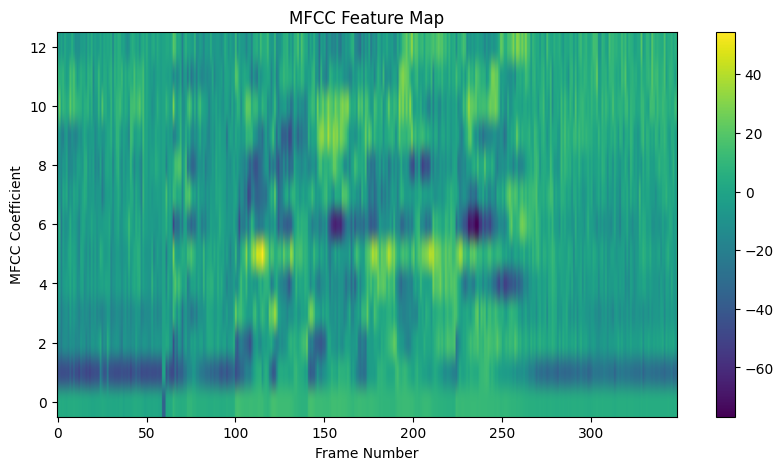

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.imshow(
    mfcc_features.T,
    aspect='auto',
    origin='lower'
)

plt.colorbar()
plt.xlabel("Frame Number")
plt.ylabel("MFCC Coefficient")
plt.title("MFCC Feature Map")

plt.show()

In [17]:
import numpy as np

feature_vector = np.mean(
    mfcc_features,
    axis=0
)

print(feature_vector.shape)
print(feature_vector)

(13,)
[  7.16072106 -19.66132328  -4.06654519  -3.63998423  -5.27169182
   5.11034692 -11.72263242  -3.50672033  -6.67643433  -0.84035492
   4.87237065   1.30343899   1.23365773]


In [18]:
import numpy as np
from scipy.io import wavfile
from python_speech_features import mfcc

def extract_features(audio_path):
    
    sample_rate, signal = wavfile.read(audio_path)

    # convert to float
    signal = signal.astype(np.float32)

    # normalize
    signal = signal / np.max(np.abs(signal))

    # MFCC extraction
    mfcc_features = mfcc(signal, sample_rate)

    # fixed-size vector
    feature_vector = np.mean(
        mfcc_features,
        axis=0
    )

    return feature_vector

In [19]:
sample_audio = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/Actor_07/03-01-07-01-01-02-07.wav"

features = extract_features(sample_audio)

print(features.shape)
print(features)

(13,)
[ -7.60251879 -19.66132707  -4.06655019  -3.6399898   -5.27169699
   5.11034219 -11.72263636  -3.50672366  -6.67643715  -0.84035699
   4.87236893   1.30343783   1.23365698]


In [20]:
import os

X = []
y = []

In [21]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

In [24]:
for actor in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):

        if not file.endswith(".wav"):
            continue

        filepath = os.path.join(actor_path, file)

        try:

            features = extract_features(filepath)

            emotion_code = file.split("-")[2]

            emotion = emotion_map[emotion_code]

            X.append(features)
            y.append(emotion)

        except Exception as e:

            print("Error:", filepath)
            print(e)

In [25]:
import numpy as np

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (4320, 13)
y Shape: (4320,)


In [26]:
from collections import Counter

Counter(y)

Counter({np.str_('surprised'): 576,
         np.str_('neutral'): 288,
         np.str_('disgust'): 576,
         np.str_('fearful'): 576,
         np.str_('sad'): 576,
         np.str_('calm'): 576,
         np.str_('happy'): 576,
         np.str_('angry'): 576})

In [27]:
import pandas as pd

df = pd.DataFrame(X)

df["emotion"] = y

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,emotion
0,-11.659542,-14.234751,-7.067406,-4.548058,-5.074553,0.847016,-15.553657,0.776011,-6.316433,-2.521836,-0.799866,-1.731571,-2.510620,surprised
1,-12.356051,-11.960166,-3.545730,-4.295530,-4.485585,-0.648135,-12.019033,1.144422,-6.775476,-1.459859,-2.072242,1.043510,-1.525852,neutral
2,-11.524143,-12.834068,-7.964316,-1.807626,-5.218595,-2.794836,-10.234705,3.376384,-4.020189,-3.069685,-4.280426,1.363211,-2.044234,disgust
3,-12.924011,-8.118405,-8.733675,-3.332108,-4.608729,-3.503453,-9.294561,2.697880,-6.995384,-4.290276,-5.386862,1.324329,-0.472591,disgust
4,-10.422731,-15.657895,-2.498542,-4.018549,-5.665871,-0.131134,-11.426143,1.795012,-6.405399,-3.786209,-3.500886,0.134154,-1.890372,neutral


In [28]:
print(X.shape)
print(y.shape)
print(df.head())

(4320, 13)
(4320,)
           0          1         2         3         4         5          6  \
0 -11.659542 -14.234751 -7.067406 -4.548058 -5.074553  0.847016 -15.553657   
1 -12.356051 -11.960166 -3.545730 -4.295530 -4.485585 -0.648135 -12.019033   
2 -11.524143 -12.834068 -7.964316 -1.807626 -5.218595 -2.794836 -10.234705   
3 -12.924011  -8.118405 -8.733675 -3.332108 -4.608729 -3.503453  -9.294561   
4 -10.422731 -15.657895 -2.498542 -4.018549 -5.665871 -0.131134 -11.426143   

          7         8         9        10        11        12    emotion  
0  0.776011 -6.316433 -2.521836 -0.799866 -1.731571 -2.510620  surprised  
1  1.144422 -6.775476 -1.459859 -2.072242  1.043510 -1.525852    neutral  
2  3.376384 -4.020189 -3.069685 -4.280426  1.363211 -2.044234    disgust  
3  2.697880 -6.995384 -4.290276 -5.386862  1.324329 -0.472591    disgust  
4  1.795012 -6.405399 -3.786209 -3.500886  0.134154 -1.890372    neutral  


In [29]:
print(len(df))
print(len(set(df.index)))

4320
4320


In [30]:
from collections import Counter

print(Counter(y))

Counter({np.str_('surprised'): 576, np.str_('disgust'): 576, np.str_('fearful'): 576, np.str_('sad'): 576, np.str_('calm'): 576, np.str_('happy'): 576, np.str_('angry'): 576, np.str_('neutral'): 288})


In [31]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [32]:
for emotion, label in zip(
    encoder.classes_,
    range(len(encoder.classes_))
):
    print(label, "->", emotion)

0 -> angry
1 -> calm
2 -> disgust
3 -> fearful
4 -> happy
5 -> neutral
6 -> sad
7 -> surprised


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [34]:
print(X_train.shape)
print(X_test.shape)

(3456, 13)
(864, 13)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [36]:
print(X_train_scaled.mean())
print(X_train_scaled.std())

-6.556958205264814e-16
1.0


In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(
    X_train_scaled,
    y_train
)

predictions = knn.predict(
    X_test_scaled
)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.7164351851851852


In [38]:
import math

def euclidean_distance(point1, point2):
    
    distance = 0
    
    for i in range(len(point1)):
        distance += (point1[i] - point2[i]) ** 2
    
    return math.sqrt(distance)

In [39]:
print(
    euclidean_distance(
        X_train_scaled[0],
        X_train_scaled[1]
    )
)

5.624572386276882


In [40]:
def get_neighbors(
        X_train,
        y_train,
        test_sample,
        k=5):

    distances = []

    for i in range(len(X_train)):

        distance = euclidean_distance(
            test_sample,
            X_train[i]
        )

        distances.append(
            (distance, y_train[i])
        )

    distances.sort(key=lambda x: x[0])

    neighbors = distances[:k]

    return neighbors

In [41]:
neighbors = get_neighbors(
    X_train_scaled,
    y_train,
    X_test_scaled[0],
    k=5
)

print(neighbors)

[(0.0, np.int64(1)), (0.0, np.int64(1)), (1.5396504819994155, np.int64(1)), (1.5396504819994155, np.int64(1)), (1.7374150006519749, np.int64(1))]


In [42]:
from collections import Counter

def predict_classification(
        X_train,
        y_train,
        test_sample,
        k=5):

    neighbors = get_neighbors(
        X_train,
        y_train,
        test_sample,
        k
    )

    labels = []

    for _, label in neighbors:
        labels.append(label)

    prediction = Counter(labels).most_common(1)[0][0]

    return prediction

In [43]:
prediction = predict_classification(
    X_train_scaled,
    y_train,
    X_test_scaled[0],
    k=5
)

print("Predicted:", prediction)
print("Actual:", y_test[0])

Predicted: 1
Actual: 1


In [44]:
emotion = encoder.inverse_transform([prediction])

print(emotion[0])

calm


In [45]:
predictions = []

for sample in X_test_scaled[:20]:

    pred = predict_classification(
        X_train_scaled,
        y_train,
        sample,
        k=5
    )

    predictions.append(pred)

print(predictions[:10])

[np.int64(1), np.int64(4), np.int64(6), np.int64(7), np.int64(1), np.int64(6), np.int64(1), np.int64(5), np.int64(0), np.int64(6)]


In [46]:
from sklearn.metrics import accuracy_score

small_predictions = []

for sample in X_test_scaled[:50]:

    pred = predict_classification(
        X_train_scaled,
        y_train,
        sample,
        k=5
    )

    small_predictions.append(pred)

small_accuracy = accuracy_score(
    y_test[:50],
    small_predictions
)

print("Accuracy:", small_accuracy)

Accuracy: 0.78


In [47]:
predictions = []

for sample in X_test_scaled:

    pred = predict_classification(
        X_train_scaled,
        y_train,
        sample,
        k=5
    )

    predictions.append(pred)

In [48]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Final Accuracy:", accuracy)


Final Accuracy: 0.7442129629629629


In [49]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(
    y_test,
    predictions
)

cm_df = pd.DataFrame(
    cm,
    index=encoder.classes_,
    columns=encoder.classes_
)

cm_df

,angry,calm,disgust,fearful,happy,neutral,sad,surprised
angry,81,3,5,7,5,4,4,6
calm,2,90,0,0,2,14,7,0
disgust,11,4,78,5,5,0,4,8
fearful,4,0,0,84,6,4,10,7
happy,7,2,0,7,82,1,9,7
neutral,0,3,1,0,2,51,1,0
sad,2,5,6,6,1,2,87,6
surprised,3,3,3,2,5,3,7,90


In [50]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        predictions,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.74      0.70      0.72       115
        calm       0.82      0.78      0.80       115
     disgust       0.84      0.68      0.75       115
     fearful       0.76      0.73      0.74       115
       happy       0.76      0.71      0.74       115
     neutral       0.65      0.88      0.74        58
         sad       0.67      0.76      0.71       115
   surprised       0.73      0.78      0.75       116

    accuracy                           0.74       864
   macro avg       0.74      0.75      0.74       864
weighted avg       0.75      0.74      0.74       864



In [51]:
import pickle

model_data = {
    "X_train": X_train_scaled,
    "y_train": y_train,
    "label_encoder": encoder,
    "scaler": scaler,
    "k": 5
}

with open("emotion_knn_model.pkl", "wb") as file:
    pickle.dump(model_data, file)

print("Model Saved")

Model Saved


In [52]:
def predict_emotion(audio_path):

    features = extract_features(audio_path)

    features = scaler.transform(
        features.reshape(1, -1)
    )[0]

    prediction = predict_classification(
        X_train_scaled,
        y_train,
        features,
        k=5
    )

    emotion = encoder.inverse_transform(
        [prediction]
    )[0]

    return emotion